In [ ]:
# !gdown 10mUC9P8kfHxfc9JCh-CBFE9pIj8lnYIo
# !gdown 1fJf1wesxVRpaCDWN7245xqti1w1MQCEv

/home/clown2/Desktop/Work/Research/wm_cbf
Encoder CNN shapes: {'image': (128, 128, 3)}
Encoder MLP shapes: {'obs_state': (2,)}


/home/clown2/anaconda3/envs/wm_cbf/lib/python3.12/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Decoder CNN shapes: {'image': (128, 128, 3)}
Decoder MLP shapes: {'obs_state': (2,)}


/home/clown2/Desktop/Work/Research/wm_cbf/PytorchReachability/dreamerv3-torch/tools.py:888: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Optimizer model_opt has 27002886 variables.


/home/clown2/anaconda3/envs/wm_cbf/lib/python3.12/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Grid shape: torch.Size([2500, 3])
The timed block took 9.130609 seconds.
Values shape: (50, 50)


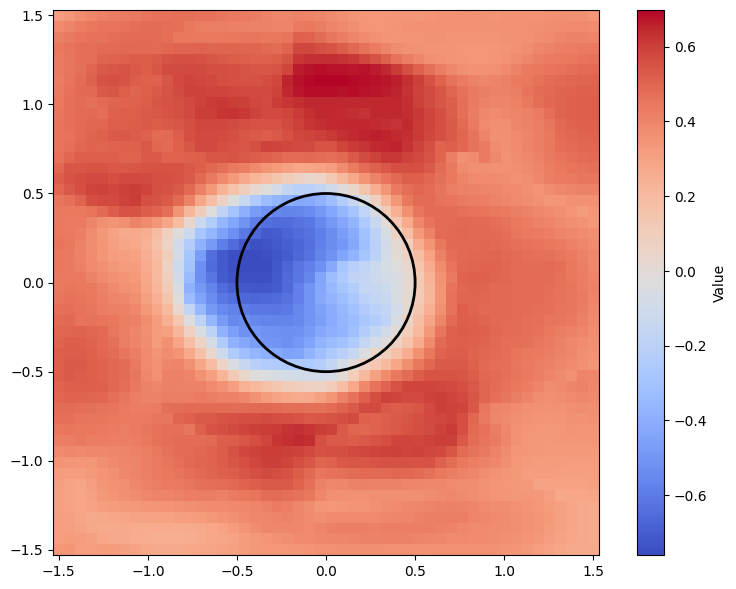

In [1]:
import os, sys, torch, time
from latent_dubins_ca_wm_pil import LatentDubinContinuousAction

dreamer_dir = 'PytorchReachability/dreamerv3-torch'
sys.path.append(os.path.abspath(dreamer_dir))
import tools, collections 

val_fn = LatentDubinContinuousAction()

# create a grid of data, it should be 3xN, each of the N column should be [x,y,theta], theta is all 0, x and y should fill a grid of 100 x 100 points spanning from val_fn.args.x_min to val_fn.args.x_max and val_fn.args.y_min to val_fn.args.y_max
x_min = -1.5
x_max = 1.5

x = torch.linspace(x_min, x_max, 50)
y = torch.linspace(x_min, x_max, 50)
X, Y = torch.meshgrid(x, y)
grid = torch.stack([X.flatten(), Y.flatten(), 0*torch.pi*torch.ones_like(X.flatten())], dim=1)

print("Grid shape:", grid.shape)

start = time.perf_counter()
values = val_fn.priv_state_to_V(grid[:,:])
end = time.perf_counter()

# Code after the timed block
duration = end - start
print(f"The timed block took {duration:.6f} seconds.")

x_vals = grid[:, 0].reshape(X.shape)
y_vals = grid[:, 1].reshape(Y.shape)
values = values.reshape(X.shape)

print("Values shape:", values.shape)


import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Create the pixelated map
fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(x_vals, y_vals, values, cmap='coolwarm')
plt.colorbar(mesh, label='Value')

# Add circle centered at (0,0) with radius 0.5
circle = Circle((0, 0), 0.5, fill=False, edgecolor='black', linestyle='-', linewidth=2)
ax.add_patch(circle)

ax.set_aspect('equal')
plt.tight_layout()
plt.show()


/home/clown2/Desktop/Work/Research/wm_cbf
Encoder CNN shapes: {'image': (128, 128, 3)}
Encoder MLP shapes: {'obs_state': (2,)}


/home/clown2/anaconda3/envs/wm_cbf/lib/python3.12/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Decoder CNN shapes: {'image': (128, 128, 3)}
Decoder MLP shapes: {'obs_state': (2,)}


/home/clown2/Desktop/Work/Research/wm_cbf/PytorchReachability/dreamerv3-torch/tools.py:917: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Optimizer model_opt has 27002886 variables.


/home/clown2/anaconda3/envs/wm_cbf/lib/python3.12/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Grid shape: torch.Size([2500, 3])
The timed block took 9.099984 seconds.
Values shape: (50, 50)


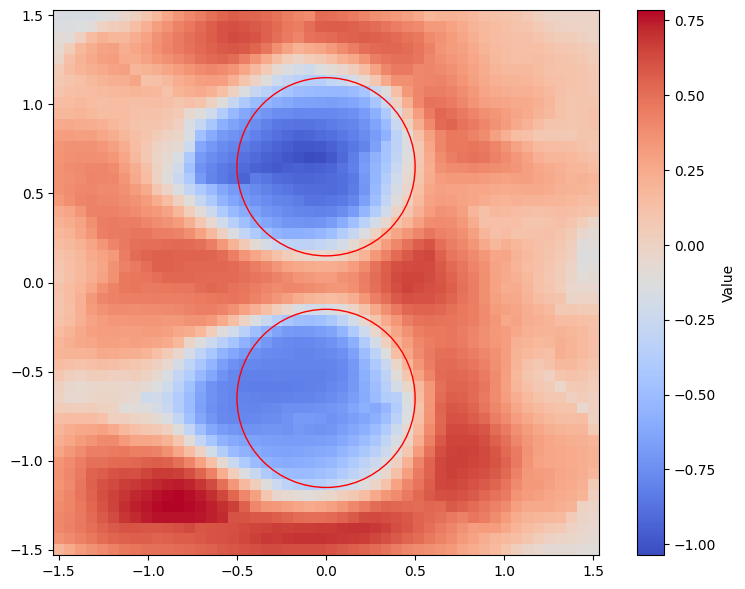

In [1]:
import os, sys, torch, time
from latent_dubins_gap import LatentDubinGap

dreamer_dir = 'PytorchReachability/dreamerv3-torch'
sys.path.append(os.path.abspath(dreamer_dir))
import tools, collections 

val_fn = LatentDubinGap()

# create a grid of data, it should be 3xN, each of the N column should be [x,y,theta], theta is all 0, x and y should fill a grid of 100 x 100 points spanning from val_fn.args.x_min to val_fn.args.x_max and val_fn.args.y_min to val_fn.args.y_max
x_min = -1.5
x_max = 1.5

x = torch.linspace(x_min, x_max, 50)
y = torch.linspace(x_min, x_max, 50)
X, Y = torch.meshgrid(x, y)
grid = torch.stack([X.flatten(), Y.flatten(), 0*torch.pi/2*torch.ones_like(X.flatten())], dim=1)

print("Grid shape:", grid.shape)

start = time.perf_counter()
values = val_fn.priv_state_to_V(grid[:,:])
end = time.perf_counter()

# Code after the timed block
duration = end - start
print(f"The timed block took {duration:.6f} seconds.")

x_vals = grid[:, 0].reshape(X.shape)
y_vals = grid[:, 1].reshape(Y.shape)
values = values.reshape(X.shape)

print("Values shape:", values.shape)


import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Create the pixelated map
fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(x_vals, y_vals, values, cmap='coolwarm')
plt.colorbar(mesh, label='Value')

# Add circle centered at (0,0) with radius 0.5
for x_obs, y_obs, r_obs in zip(val_fn.args.obs_x, val_fn.args.obs_y, val_fn.args.obs_r):
    circle = Circle((x_obs, y_obs), r_obs, edgecolor=(1,0,0), facecolor='none')
    ax.add_patch(circle)

ax.set_aspect('equal')
plt.tight_layout()
plt.show()


/home/clown2/Desktop/Work/Research/wm_cbf
Encoder CNN shapes: {'image': (128, 128, 3)}
Encoder MLP shapes: {'obs_state': (2,)}


/home/clown2/anaconda3/envs/wm_cbf/lib/python3.12/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Decoder CNN shapes: {'image': (128, 128, 3)}
Decoder MLP shapes: {'obs_state': (2,)}
Optimizer model_opt has 27002886 variables.


/home/clown2/Desktop/Work/Research/wm_cbf/PytorchReachability/dreamerv3-torch/tools.py:889: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Grid shape: torch.Size([2500, 3])
The timed block took 8.925244 seconds.
Values shape: (50, 50)


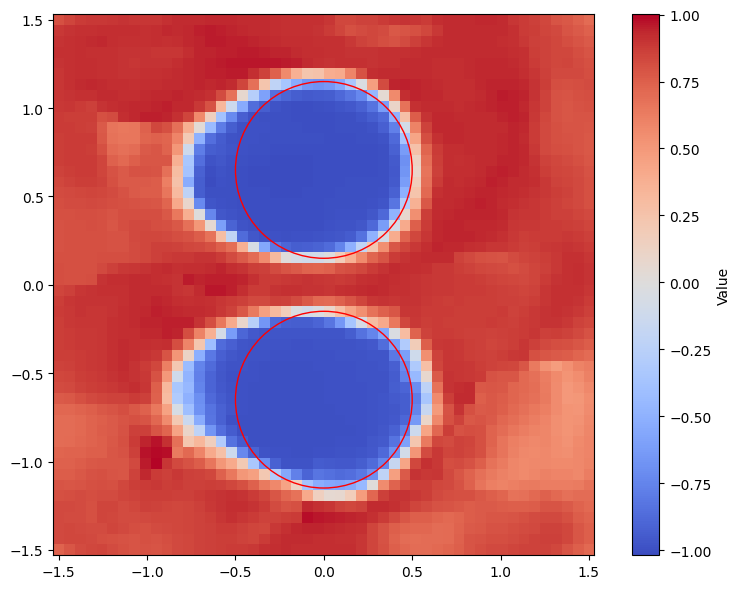

In [2]:
import os, sys, torch, time
from latent_dubins_gap_nogp import LatentDubinGapNoGP

dreamer_dir = 'PytorchReachability/dreamerv3-torch'
sys.path.append(os.path.abspath(dreamer_dir))
import tools, collections 

val_fn = LatentDubinGapNoGP()

# create a grid of data, it should be 3xN, each of the N column should be [x,y,theta], theta is all 0, x and y should fill a grid of 100 x 100 points spanning from val_fn.args.x_min to val_fn.args.x_max and val_fn.args.y_min to val_fn.args.y_max
x_min = -1.5
x_max = 1.5

x = torch.linspace(x_min, x_max, 50)
y = torch.linspace(x_min, x_max, 50)
X, Y = torch.meshgrid(x, y)
grid = torch.stack([X.flatten(), Y.flatten(), 0*torch.pi*torch.ones_like(X.flatten())], dim=1)

print("Grid shape:", grid.shape)

start = time.perf_counter()
values = val_fn.priv_state_to_V(grid[:,:])
end = time.perf_counter()

# Code after the timed block
duration = end - start
print(f"The timed block took {duration:.6f} seconds.")

x_vals = grid[:, 0].reshape(X.shape)
y_vals = grid[:, 1].reshape(Y.shape)
values = values.reshape(X.shape)

print("Values shape:", values.shape)


import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Create the pixelated map
fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(x_vals, y_vals, values, cmap='coolwarm')
plt.colorbar(mesh, label='Value')

# Add circle centered at (0,0) with radius 0.5
for x_obs, y_obs, r_obs in zip(val_fn.args.obs_x, val_fn.args.obs_y, val_fn.args.obs_r):
    circle = Circle((x_obs, y_obs), r_obs, edgecolor=(1,0,0), facecolor='none')
    ax.add_patch(circle)

ax.set_aspect('equal')
plt.tight_layout()
plt.show()


In [ ]:
import os, sys, torch, time
from latent_dubins_gap_nogp import LatentDubinGapNoGP

dreamer_dir = 'PytorchReachability/dreamerv3-torch'
sys.path.append(os.path.abspath(dreamer_dir))
import tools, collections 

val_fn = LatentDubinGapNoGP()

# create a grid of data, it should be 3xN, each of the N column should be [x,y,theta], theta is all 0, x and y should fill a grid of 100 x 100 points spanning from val_fn.args.x_min to val_fn.args.x_max and val_fn.args.y_min to val_fn.args.y_max
x_min = -1.5
x_max = 1.5

x = torch.linspace(x_min, x_max, 50)
y = torch.linspace(x_min, x_max, 50)
X, Y = torch.meshgrid(x, y)
grid = torch.stack([X.flatten(), Y.flatten(), 0*torch.pi*torch.ones_like(X.flatten())], dim=1)

print("Grid shape:", grid.shape)

start = time.perf_counter()
values = val_fn.priv_state_to_V(grid[:,:])
end = time.perf_counter()

# Code after the timed block
duration = end - start
print(f"The timed block took {duration:.6f} seconds.")

x_vals = grid[:, 0].reshape(X.shape)
y_vals = grid[:, 1].reshape(Y.shape)
values = values.reshape(X.shape)

print("Values shape:", values.shape)


import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Create the pixelated map
fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(x_vals, y_vals, values, cmap='coolwarm')
plt.colorbar(mesh, label='Value')

# Add circle centered at (0,0) with radius 0.5
for x_obs, y_obs, r_obs in zip(val_fn.args.obs_x, val_fn.args.obs_y, val_fn.args.obs_r):
    circle = Circle((x_obs, y_obs), r_obs, edgecolor=(1,0,0), facecolor='none')
    ax.add_patch(circle)

ax.set_aspect('equal')
plt.tight_layout()
plt.show()
